## Laboratorio 05: Clasificación Multiclase

### Clasificación de Dígitos Árabes Manuscritos mediante Regresión Logística One-vs-All


**Estudiante:** Carlos Daniel Kevin Apaza Villca - Oyente

**Dataset:** Arabic Handwritten Digits Dataset (AHDD)

**Objetivo:** Implementar un modelo de clasificación multiclase mediante
Regresión Logística One-vs-All para reconocer dígitos árabes manuscritos.

##1. librerías y Google Drive

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


##2. Carga del Dataset

In [2]:
# Ruta donde se encuentran los archivos del dataset
ruta = '/content/gdrive/MyDrive/Inteligencia Artificial 1 - Kevin/Laboratorios/Laboratorio 05 - Clasificacion Multiclase/dataset/'

# Cargar datos de entrenamiento
X_train = pd.read_csv(
    ruta + 'csvTrainImages 60k x 784.csv',
    header=None
).values

y_train = pd.read_csv(
    ruta + 'csvTrainLabel 60k x 1.csv',
    header=None
).values.flatten()

# Cargar datos de prueba
X_test = pd.read_csv(
    ruta + 'csvTestImages 10k x 784.csv',
    header=None
).values

y_test = pd.read_csv(
    ruta + 'csvTestLabel 10k x 1.csv',
    header=None
).values.flatten()

print("Dataset cargado correctamente.\n")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

Dataset cargado correctamente.

X_train: (60000, 784)
y_train: (60000,)

X_test: (10000, 784)
y_test: (10000,)


## 3. Exploración del Dataset (comprobar las clases)

In [3]:
# Revisar las clases existentes
clases, cantidades = np.unique(y_train, return_counts=True)

print("Clases encontradas:")
print(clases)

print("\nNúmero de clases:", len(clases))

print("\nCantidad de imágenes por clase:")
for clase, cantidad in zip(clases, cantidades):
    print(f"Clase {clase}: {cantidad} imágenes")

Clases encontradas:
[0 1 2 3 4 5 6 7 8 9]

Número de clases: 10

Cantidad de imágenes por clase:
Clase 0: 6000 imágenes
Clase 1: 6000 imágenes
Clase 2: 6000 imágenes
Clase 3: 6000 imágenes
Clase 4: 6000 imágenes
Clase 5: 6000 imágenes
Clase 6: 6000 imágenes
Clase 7: 6000 imágenes
Clase 8: 6000 imágenes
Clase 9: 6000 imágenes


## 4. Preprocesamiento de los Datos

In [4]:
# Comprobar tipos de datos
print("Tipo de X_train:", X_train.dtype)
print("Tipo de y_train:", y_train.dtype)

# Comprobar valores nulos
print("\nValores nulos:")
print("X_train:", np.isnan(X_train).sum())
print("y_train:", np.isnan(y_train).sum())
print("X_test :", np.isnan(X_test).sum())
print("y_test :", np.isnan(y_test).sum())

# Comprobar rango de valores de los píxeles
print("\nRango de los píxeles:")
print("Valor mínimo:", X_train.min())
print("Valor máximo:", X_train.max())

Tipo de X_train: int64
Tipo de y_train: int64

Valores nulos:
X_train: 0
y_train: 0
X_test : 0
y_test : 0

Rango de los píxeles:
Valor mínimo: 0
Valor máximo: 255


Visualizando las Imagenes

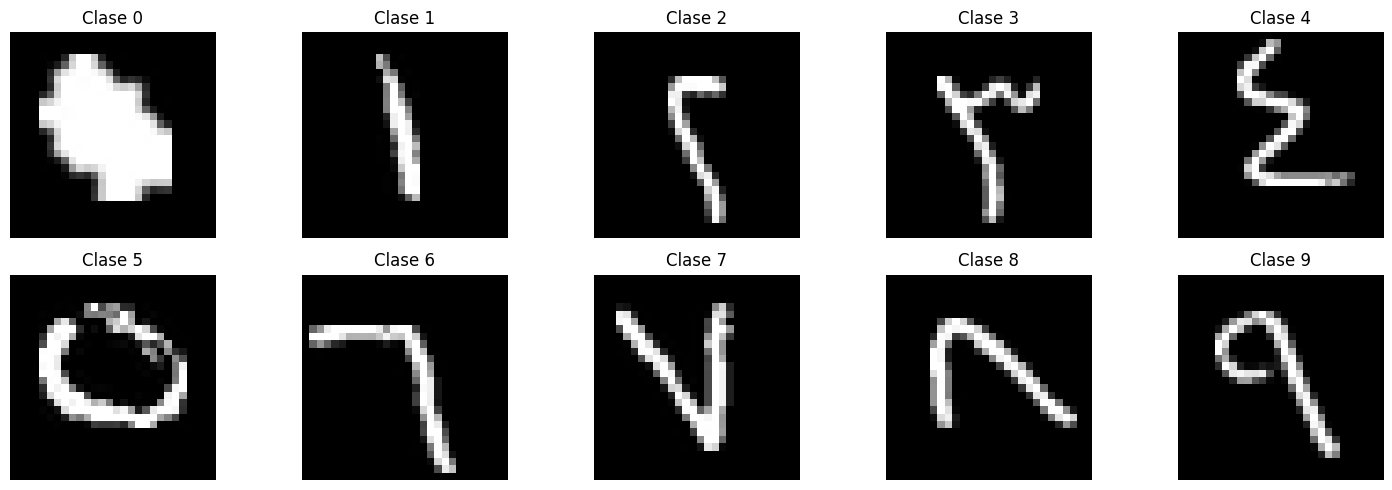

In [8]:
# Visualizar un ejemplo de cada clase

plt.figure(figsize=(15, 5))

for clase in range(10):
    indice = np.where(y_train == clase)[0][0]

    imagen = X_train[indice].reshape(28, 28).T

    plt.subplot(2, 5, clase + 1)
    plt.imshow(imagen, cmap='gray')
    plt.title(f'Clase {clase}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## 5. Normalización de los Datos

In [9]:
# Convertir los valores de los píxeles del rango 0-255 al rango 0-1

X_train = X_train.astype(float) / 255.0
X_test = X_test.astype(float) / 255.0

print("Normalización completada.")

print("\nNuevo rango de X_train:")
print("Valor mínimo:", X_train.min())
print("Valor máximo:", X_train.max())

print("\nNuevo rango de X_test:")
print("Valor mínimo:", X_test.min())
print("Valor máximo:", X_test.max())

Normalización completada.

Nuevo rango de X_train:
Valor mínimo: 0.0
Valor máximo: 1.0

Nuevo rango de X_test:
Valor mínimo: 0.0
Valor máximo: 1.0


## 6. Balanceo de Clases

In [10]:
# Comprobar la distribución de clases en entrenamiento y prueba

clases_train, cantidades_train = np.unique(y_train, return_counts=True)
clases_test, cantidades_test = np.unique(y_test, return_counts=True)

print("Distribución del conjunto de entrenamiento:")
for clase, cantidad in zip(clases_train, cantidades_train):
    print(f"Clase {clase}: {cantidad} imágenes")

print("\nDistribución del conjunto de prueba:")
for clase, cantidad in zip(clases_test, cantidades_test):
    print(f"Clase {clase}: {cantidad} imágenes")

Distribución del conjunto de entrenamiento:
Clase 0: 6000 imágenes
Clase 1: 6000 imágenes
Clase 2: 6000 imágenes
Clase 3: 6000 imágenes
Clase 4: 6000 imágenes
Clase 5: 6000 imágenes
Clase 6: 6000 imágenes
Clase 7: 6000 imágenes
Clase 8: 6000 imágenes
Clase 9: 6000 imágenes

Distribución del conjunto de prueba:
Clase 0: 1000 imágenes
Clase 1: 1000 imágenes
Clase 2: 1000 imágenes
Clase 3: 1000 imágenes
Clase 4: 1000 imágenes
Clase 5: 1000 imágenes
Clase 6: 1000 imágenes
Clase 7: 1000 imágenes
Clase 8: 1000 imágenes
Clase 9: 1000 imágenes


**Conclusión:** El dataset se encuentra balanceado, ya que todas las clases poseen la misma cantidad de ejemplos. Por lo tanto, no es necesario aplicar técnicas adicionales de balanceo.

## 7. División del Dataset

In [11]:
# El dataset ya proporciona conjuntos separados de entrenamiento y prueba

total_datos = len(X_train) + len(X_test)

porcentaje_train = (len(X_train) / total_datos) * 100
porcentaje_test = (len(X_test) / total_datos) * 100

print("Total de imágenes:", total_datos)

print("\nConjunto de entrenamiento:")
print("Cantidad:", len(X_train))
print(f"Porcentaje: {porcentaje_train:.2f}%")

print("\nConjunto de prueba:")
print("Cantidad:", len(X_test))
print(f"Porcentaje: {porcentaje_test:.2f}%")

Total de imágenes: 70000

Conjunto de entrenamiento:
Cantidad: 60000
Porcentaje: 85.71%

Conjunto de prueba:
Cantidad: 10000
Porcentaje: 14.29%


El dataset AHDD proporciona originalmente los conjuntos de entrenamiento y prueba por separado. Por esta razón, se conserva la división original de 60.000 imágenes para entrenamiento y 10.000 imágenes para prueba.

## 8. Regresión Logística Multiclase One-vs-All

###8.1 Preparar X y agregar el término de sesgo.

Como cada imagen tiene 784 características, agregaremos una columna de unos para representar θ₀.

In [12]:
# Agregar una columna de unos para el término independiente (bias)

m_train = X_train.shape[0]
m_test = X_test.shape[0]

X_train_bias = np.concatenate(
    [np.ones((m_train, 1)), X_train],
    axis=1
)

X_test_bias = np.concatenate(
    [np.ones((m_test, 1)), X_test],
    axis=1
)

print("Dimensión original X_train:", X_train.shape)
print("Dimensión con bias X_train:", X_train_bias.shape)

print("\nDimensión original X_test:", X_test.shape)
print("Dimensión con bias X_test:", X_test_bias.shape)

Dimensión original X_train: (60000, 784)
Dimensión con bias X_train: (60000, 785)

Dimensión original X_test: (10000, 784)
Dimensión con bias X_test: (10000, 785)


El 785 sale de:

784 píxeles + 1 término de sesgo = 785 parámetros.

### 8.2 Función Sigmoide

In [13]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

La regresión logística utiliza:

g(z)=1+e−z1​

y transforma el resultado en una probabilidad entre 0 y 1.

In [14]:
# Comprobando
print("sigmoid(0) =", sigmoid(0))
print("sigmoid(5) =", sigmoid(5))
print("sigmoid(-5) =", sigmoid(-5))

sigmoid(0) = 0.5
sigmoid(5) = 0.9933071490757153
sigmoid(-5) = 0.0066928509242848554


### 8.3 Función de Costo Regularizada

In [16]:
def lrCostFunction(theta, X, y, lambda_):
    m = len(y)

    # Predicción
    h = sigmoid(X @ theta)

    # Evitar log(0)
    epsilon = 1e-10
    h = np.clip(h, epsilon, 1 - epsilon)

    # Costo de regresión logística
    J = (-1 / m) * (
        y @ np.log(h) +
        (1 - y) @ np.log(1 - h)
    )

    # Regularización (sin regularizar theta[0])
    regularizacion = (lambda_ / (2 * m)) * np.sum(theta[1:] ** 2)

    J = J + regularizacion

    # Gradiente
    grad = (1 / m) * (X.T @ (h - y))

    # Regularización del gradiente
    grad[1:] = grad[1:] + (lambda_ / m) * theta[1:]

    return J, grad

Probar la función de costo regularizada

In [17]:
# Probar la función de costo regularizada

theta_inicial = np.zeros(X_train_bias.shape[1])

# Para probar la clase 0 contra todas las demás
y_binaria = (y_train == 0).astype(int)

lambda_ = 1

costo_inicial, gradiente_inicial = lrCostFunction(
    theta_inicial,
    X_train_bias,
    y_binaria,
    lambda_
)

print("Costo inicial para la clase 0:", costo_inicial)
print("Tamaño del gradiente:", gradiente_inicial.shape)
print("Primeros 5 valores del gradiente:")
print(gradiente_inicial[:5])

Costo inicial para la clase 0: 0.6931471805599183
Tamaño del gradiente: (785,)
Primeros 5 valores del gradiente:
[4.00000000e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 3.26797386e-08]


###8.4 Entrenamiento One-vs-All

In [18]:
from scipy.optimize import minimize

In [20]:
def oneVsAll(X, y, num_labels, lambda_):
    """
    Entrena un clasificador de regresión logística
    para cada una de las clases.
    """

    n = X.shape[1]

    # Una fila de theta para cada clase
    all_theta = np.zeros((num_labels, n))

    # Guardaremos el costo final de cada clasificador
    costos = []

    for clase in range(num_labels):

        print(f"Entrenando clasificador para la clase {clase}...")

        # Convertir el problema en binario:
        # 1 = pertenece a la clase
        # 0 = pertenece a cualquier otra clase
        y_binaria = (y == clase).astype(int)

        theta_inicial = np.zeros(n)

        resultado = minimize(
            fun=lambda theta: lrCostFunction(
                theta,
                X,
                y_binaria,
                lambda_
            ),
            x0=theta_inicial,
            jac=True,
            method='L-BFGS-B',
            options={'maxiter': 100}
        )

        # Guardar los parámetros encontrados
        all_theta[clase, :] = resultado.x

        # Guardar costo final
        costos.append(resultado.fun)

        print(f"Clase {clase} terminada - Costo: {resultado.fun:.6f}\n")

    return all_theta, costos

### 8.5 Ejecución del Entrenamiento

In [21]:
num_labels = 10
lambda_ = 1

all_theta, costos = oneVsAll(
    X_train_bias,
    y_train,
    num_labels,
    lambda_
)

print("Entrenamiento completado.")
print("Dimensión de all_theta:", all_theta.shape)

Entrenando clasificador para la clase 0...
Clase 0 terminada - Costo: 0.018460

Entrenando clasificador para la clase 1...
Clase 1 terminada - Costo: 0.012053

Entrenando clasificador para la clase 2...
Clase 2 terminada - Costo: 0.020022

Entrenando clasificador para la clase 3...
Clase 3 terminada - Costo: 0.026064

Entrenando clasificador para la clase 4...
Clase 4 terminada - Costo: 0.036969

Entrenando clasificador para la clase 5...
Clase 5 terminada - Costo: 0.024551

Entrenando clasificador para la clase 6...
Clase 6 terminada - Costo: 0.012629

Entrenando clasificador para la clase 7...
Clase 7 terminada - Costo: 0.009751

Entrenando clasificador para la clase 8...
Clase 8 terminada - Costo: 0.014498

Entrenando clasificador para la clase 9...
Clase 9 terminada - Costo: 0.048815

Entrenamiento completado.
Dimensión de all_theta: (10, 785)


## 9. Predicción Multiclase

In [22]:
def predictOneVsAll(all_theta, X):

    # Calculamos la probabilidad de cada clase
    probabilidades = sigmoid(X @ all_theta.T)

    # Elegimos la clase con mayor probabilidad
    predicciones = np.argmax(probabilidades, axis=1)

    return predicciones

## 10. Evaluación del Modelo

In [23]:
# Predicciones del conjunto de entrenamiento
pred_train = predictOneVsAll(
    all_theta,
    X_train_bias
)

# Predicciones del conjunto de prueba
pred_test = predictOneVsAll(
    all_theta,
    X_test_bias
)

# Calcular precisión
precision_train = np.mean(pred_train == y_train) * 100
precision_test = np.mean(pred_test == y_test) * 100

print(f"Precisión de entrenamiento: {precision_train:.2f}%")
print(f"Precisión de prueba: {precision_test:.2f}%")

Precisión de entrenamiento: 98.07%
Precisión de prueba: 96.67%


## 11. Gráfica del Costo por Clase

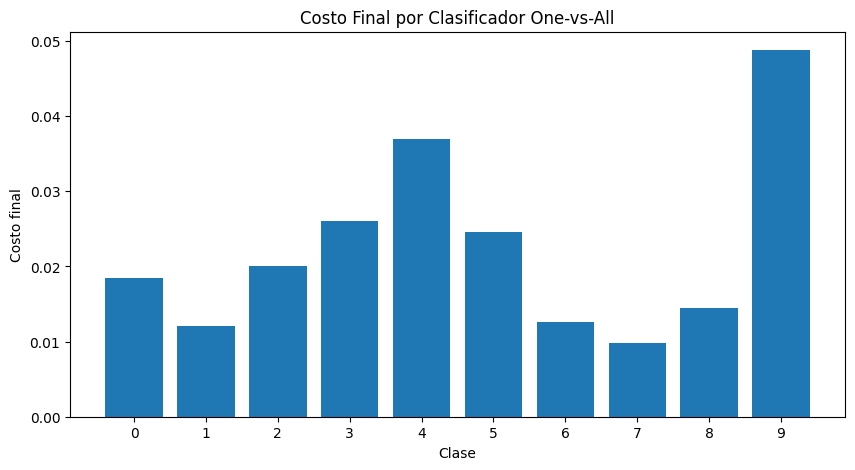

In [24]:
plt.figure(figsize=(10, 5))

plt.bar(range(10), costos)

plt.xlabel("Clase")
plt.ylabel("Costo final")
plt.title("Costo Final por Clasificador One-vs-All")
plt.xticks(range(10))

plt.show()

## 12. Ejemplos de Predicciones

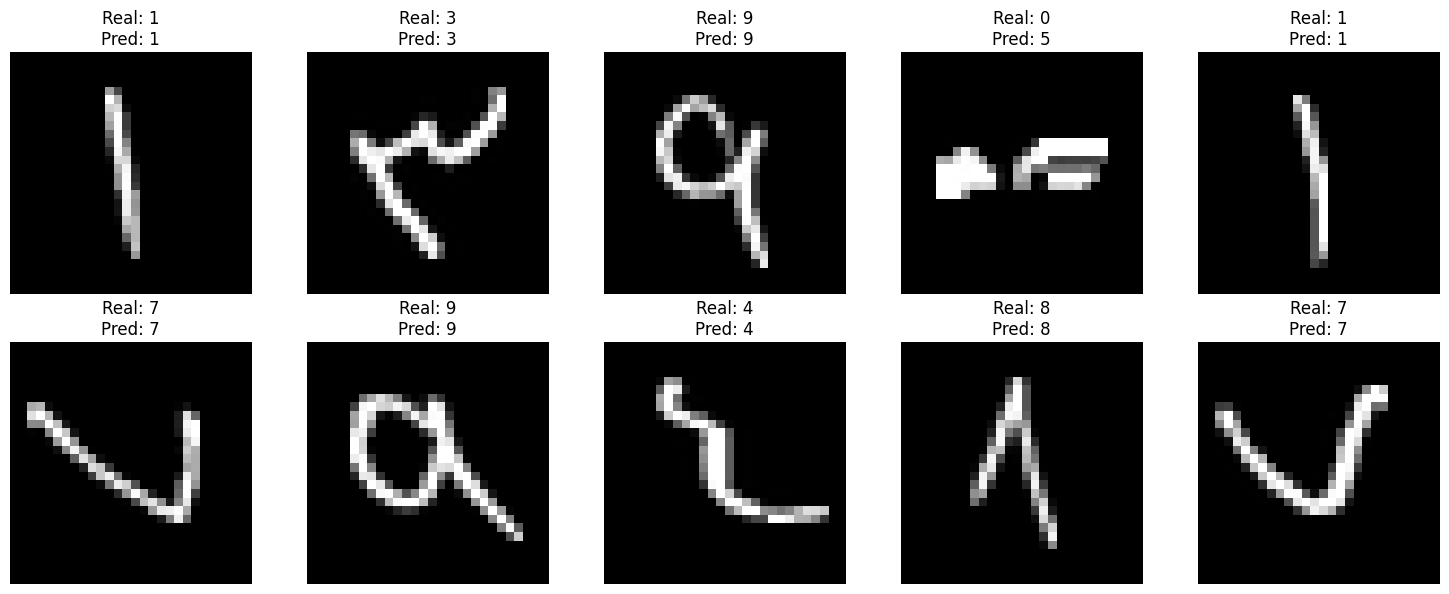

In [25]:
# Mostrar 10 ejemplos del conjunto de prueba

indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(15, 6))

for i, indice in enumerate(indices):

    imagen = X_test[indice].reshape(28, 28).T

    real = y_test[indice]
    prediccion = pred_test[indice]

    plt.subplot(2, 5, i + 1)
    plt.imshow(imagen, cmap='gray')

    plt.title(
        f"Real: {real}\nPred: {prediccion}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

## 13. Ejemplos de Predicciones Incorrectas

Cantidad de errores en prueba: 333


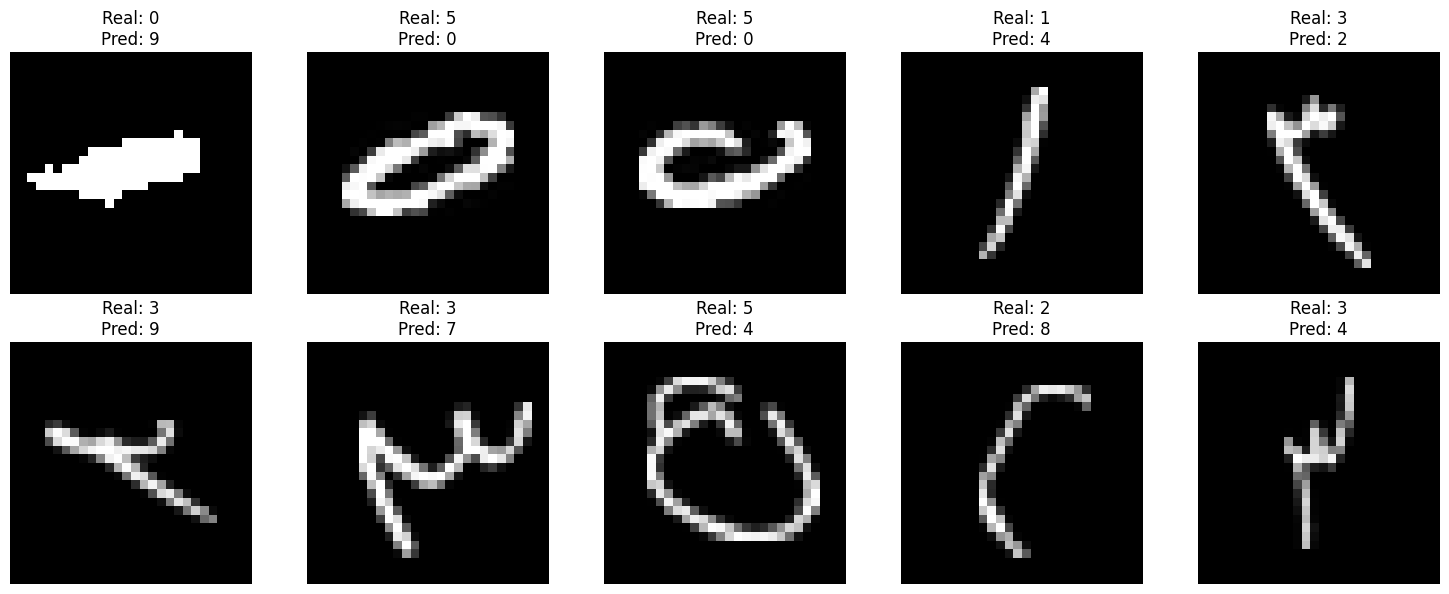

In [26]:
# Encontrar predicciones incorrectas

indices_error = np.where(pred_test != y_test)[0]

print("Cantidad de errores en prueba:", len(indices_error))

# Seleccionar hasta 10 errores
ejemplos_error = indices_error[:10]

plt.figure(figsize=(15, 6))

for i, indice in enumerate(ejemplos_error):

    imagen = X_test[indice].reshape(28, 28).T

    real = y_test[indice]
    prediccion = pred_test[indice]

    plt.subplot(2, 5, i + 1)
    plt.imshow(imagen, cmap='gray')

    plt.title(
        f"Real: {real}\nPred: {prediccion}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

## 14. Comparación de Precisión

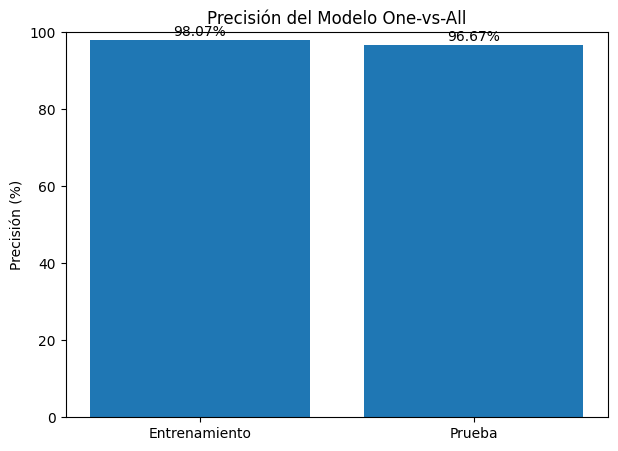

In [27]:
# Comparación de la precisión de entrenamiento y prueba

conjuntos = ['Entrenamiento', 'Prueba']
precisiones = [precision_train, precision_test]

plt.figure(figsize=(7, 5))
plt.bar(conjuntos, precisiones)

plt.ylabel('Precisión (%)')
plt.title('Precisión del Modelo One-vs-All')
plt.ylim(0, 100)

# Mostrar porcentaje sobre cada barra
for i, precision in enumerate(precisiones):
    plt.text(
        i,
        precision + 1,
        f'{precision:.2f}%',
        ha='center'
    )

plt.show()

## 15. Conclusión

Se implementó satisfactoriamente un modelo de clasificación multiclase mediante Regresión Logística One-vs-All para el reconocimiento de dígitos árabes manuscritos del dataset AHDD.

El dataset contiene 70.000 imágenes de 28×28 píxeles, distribuidas originalmente en 60.000 imágenes de entrenamiento y 10.000 imágenes de prueba. Se comprobó que las 10 clases se encuentran balanceadas y que no existen valores nulos.

Durante el preprocesamiento, los valores de los píxeles fueron normalizados del rango 0–255 al rango 0–1. Posteriormente, se entrenaron 10 clasificadores de regresión logística, uno para cada dígito, utilizando la estrategia One-vs-All y regularización.

El modelo obtuvo una precisión de **98.07% en entrenamiento** y **96.67% en prueba**, clasificando correctamente 9.667 de las 10.000 imágenes del conjunto de prueba.

Los resultados muestran que la Regresión Logística One-vs-All es capaz de realizar correctamente la clasificación multiclase de imágenes de dígitos manuscritos, obteniendo un alto nivel de generalización sobre datos no utilizados durante el entrenamiento.